# Assignment 3: Build Non-Linear Models Part 1

Juan Maldonado Franco  
DDS-8555 Predictive Analysis  
Mohamed Nabeel

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd()
for parent in [ROOT, *ROOT.parents]:
    if (parent / "DDS-8555 - Predictive Analysis").exists():
        COURSE = parent / "DDS-8555 - Predictive Analysis"
        break
else:
    COURSE = ROOT.parents[1]
DATA = COURSE / "data"
KAGGLE = DATA / "kaggle"
SUBMISSIONS = DATA / "submissions"
RANDOM_STATE = 42
pd.set_option("display.max_columns", 80)

## Conceptual Question 1

This question is answered from the definitions of the selection algorithms, not from a fitted data analysis.  For part (a), among the three k-predictor models, best subset selection has the smallest training RSS because it evaluates every possible k-predictor model and chooses the one with the lowest training RSS.  Forward and backward stepwise selection only search restricted paths through the model space, so they can match best subset selection but cannot improve on it for training RSS.  For part (b), the smallest test RSS cannot be known from the algorithm alone.  Best subset selection may overfit the training data, while a restricted stepwise path can sometimes generalize better.

For part (c), statement i is true because forward stepwise selection only adds predictors, so the k-variable forward model is nested inside the k + 1-variable forward model.  Statement ii is true because backward stepwise selection only removes predictors, so the k-variable backward model is nested inside the previous k + 1-variable backward model.  Statement iii is false because the backward path and the forward path are different searches and have no required subset relationship.  Statement iv is also false for the same reason: a forward model at size k does not have to be contained inside the backward model at size k + 1.  Statement v is false because best subset selection is not constrained to be nested across model sizes; the best k-variable model does not have to be a subset of the best k + 1-variable model (James et al., 2023).

## Applied Question 8: Simulated Selection

The simulated exercise compares forward selection, backward selection, and lasso on polynomial features.  The first data-generating process includes X, X^2, and X^3, so a good selection method should recover those terms more often than noise terms.  The final part changes the true signal to X^7, which tests whether the methods can recover a sparse high-order relationship rather than only low-order polynomial structure.

### Parts (a) and (b): Simulate X, Epsilon, and the Cubic Response

The simulation starts with a reproducible random number generator, a predictor vector X of length 100, and a noise vector epsilon of the same length.  The first response uses a cubic data-generating process, Y = 1 + 2X - 1.5X^2 + 0.75X^3 + epsilon, so the later selection methods have a known signal to recover.

In [2]:
import statsmodels.api as sm
from sklearn.linear_model import LassoCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

rng = np.random.default_rng(RANDOM_STATE)
n = 100
X_raw = rng.normal(size=n)
eps = rng.normal(size=n)
poly = pd.DataFrame({f"X^{i}": X_raw**i for i in range(1, 11)})
Y = 1 + 2 * X_raw - 1.5 * X_raw**2 + .75 * X_raw**3 + eps

display(pd.DataFrame({
    "part": ["(a)", "(b)"],
    "work_completed": [
        f"Generated X and epsilon with n={n} using numpy random generator.",
        "Generated Y = 1 + 2X - 1.5X^2 + 0.75X^3 + epsilon.",
    ],
}))
display(pd.DataFrame({"X": X_raw, "epsilon": eps, "Y": Y}).describe())

,part,work_completed
0,(a),Generated X and epsilon with n=100 using numpy...
1,(b),Generated Y = 1 + 2X - 1.5X^2 + 0.75X^3 + epsi...


,X,epsilon,Y
count,100.000000,100.000000,100.000000
mean,-0.050270,-0.010632,-0.125808
std,0.776677,0.979514,3.383023
min,-1.951035,-2.132046,-15.115513
25%,-0.543902,-0.747155,-0.564428
50%,-0.002154,-0.129715,0.650641
75%,0.535020,0.493342,1.677709
max,2.141648,2.913862,5.380752


The generated response has a known cubic structure, which gives the model-selection results a direct benchmark.  A good method does not need to select only X, X^2, and X^3 in every noisy sample, but those terms should be favored over unrelated high-order powers.

### Shared Definitions for Forward Selection, Backward Selection, and Cp

The stepwise procedures use the same polynomial design matrix, the same OLS fitting function, and Mallows' Cp computed from the full ten-term model's residual variance.  Keeping these definitions shared makes the forward and backward results comparable.

In [3]:
def fit_model(response, predictors, cols):
    Xc = sm.add_constant(predictors[list(cols)], has_constant="add")
    return sm.OLS(response, Xc).fit()

def mallows_cp(fit, sigma2, n_obs):
    rss = float(np.sum(fit.resid ** 2))
    d = len(fit.params)
    return rss / sigma2 - n_obs + 2 * d

def selection_path(response, predictors, direction):
    all_cols = list(predictors.columns)
    full_fit = fit_model(response, predictors, all_cols)
    sigma2 = full_fit.mse_resid
    chosen = [] if direction == "forward" else all_cols.copy()
    remaining = all_cols.copy()
    path = []

    for size in range(0, len(all_cols) + 1):
        fit = fit_model(response, predictors, chosen) if chosen else sm.OLS(response, np.ones((len(response), 1))).fit()
        path.append({
            "size": len(chosen),
            "predictors": tuple(chosen),
            "rss": float(np.sum(fit.resid ** 2)),
            "cp": mallows_cp(fit, sigma2, len(response)),
            "fit": fit,
        })
        if size == len(all_cols):
            break
        if direction == "forward":
            candidates = []
            for col in remaining:
                cols = chosen + [col]
                candidate_fit = fit_model(response, predictors, cols)
                candidates.append((float(np.sum(candidate_fit.resid ** 2)), col, cols))
            _, col, chosen = min(candidates, key=lambda item: item[0])
            remaining.remove(col)
        else:
            if len(chosen) == 0:
                break
            candidates = []
            for col in chosen:
                cols = [c for c in chosen if c != col]
                candidate_fit = fit_model(response, predictors, cols) if cols else sm.OLS(response, np.ones((len(response), 1))).fit()
                candidates.append((float(np.sum(candidate_fit.resid ** 2)), col, cols))
            _, _, chosen = min(candidates, key=lambda item: item[0])

    table = pd.DataFrame([{k: v for k, v in row.items() if k != "fit"} for row in path]).sort_values("size")
    best = min(path, key=lambda row: row["cp"])
    return table, best

### Part (c): Forward Stepwise Selection

Forward stepwise selection begins with the intercept-only model and adds the predictor that gives the largest RSS improvement at each step.  Mallows' Cp then selects the preferred model along that forward path.

In [4]:
forward_table, forward_best = selection_path(Y, poly, "forward")
display(forward_table[["size", "predictors", "rss", "cp"]])
display(pd.DataFrame({
    "part": ["(c)"],
    "method": ["Forward stepwise by Cp"],
    "selected_predictors": [forward_best["predictors"]],
    "cp": [forward_best["cp"]],
}))
display(forward_best["fit"].params.rename("forward_cp_coefficients"))

,size,predictors,rss,cp
0,0,(),1133.039446,1082.582586
1,1,"(X^1,)",328.868679,246.668243
2,2,"(X^1, X^2)",162.394564,75.208755
3,3,"(X^1, X^2, X^3)",91.052642,2.873276
4,4,"(X^1, X^2, X^3, X^9)",90.284786,4.073200
5,5,"(X^1, X^2, X^3, X^9, X^5)",89.636117,5.397312
6,6,"(X^1, X^2, X^3, X^9, X^5, X^8)",89.392927,7.143918
7,7,"(X^1, X^2, X^3, X^9, X^5, X^8, X^7)",88.509673,8.223601
8,8,"(X^1, X^2, X^3, X^9, X^5, X^8, X^7, X^4)",88.363839,10.071649
9,9,"(X^1, X^2, X^3, X^9, X^5, X^8, X^7, X^4, X^10)",85.836094,9.437837


,part,method,selected_predictors,cp
0,(c),Forward stepwise by Cp,"(X^1, X^2, X^3)",2.873276


const    1.116665
X^1      1.923477
X^2     -1.694628
X^3      0.844008
Name: forward_cp_coefficients, dtype: float64

The forward path gives a visible record of which terms enter as model size increases.  Because the true signal is cubic, the strongest forward result should emphasize the low-order terms even if sampling noise allows one or more additional powers to enter the Cp-preferred model.

### Part (d): Backward Stepwise Selection

Backward stepwise selection starts with all ten polynomial powers and removes one term at a time.  This creates a different search path from forward selection, so matching results are possible but not guaranteed.

In [5]:
backward_table, backward_best = selection_path(Y, poly, "backward")
display(backward_table[["size", "predictors", "rss", "cp"]])
display(pd.DataFrame({
    "part": ["(d)"],
    "method": ["Backward stepwise by Cp"],
    "selected_predictors": [backward_best["predictors"]],
    "cp": [backward_best["cp"]],
}))
display(backward_best["fit"].params.rename("backward_cp_coefficients"))

,size,predictors,rss,cp
10,0,(),1133.039446,1082.582586
9,1,"(X^3,)",392.737692,313.217244
8,2,"(X^3, X^6)",209.172242,123.949258
7,3,"(X^3, X^5, X^6)",153.896741,68.354358
6,4,"(X^3, X^5, X^6, X^8)",128.021049,43.392903
5,5,"(X^3, X^5, X^6, X^7, X^8)",115.696189,32.550883
4,6,"(X^3, X^5, X^6, X^7, X^8, X^9)",109.153003,27.733141
3,7,"(X^3, X^5, X^6, X^7, X^8, X^9, X^10)",89.050050,8.786653
2,8,"(X^1, X^3, X^5, X^6, X^7, X^8, X^9, X^10)",86.623761,8.258556
1,9,"(X^1, X^2, X^3, X^5, X^6, X^7, X^8, X^9, X^10)",85.530958,9.119897


,part,method,selected_predictors,cp
0,(d),Backward stepwise by Cp,"(X^1, X^3, X^5, X^6, X^7, X^8, X^9, X^10)",8.258556


const    0.787426
X^1      1.095073
X^3      5.273946
X^5     -6.262599
X^6     -2.561069
X^7      2.861535
X^8      1.491505
X^9     -0.368234
X^10    -0.208230
Name: backward_cp_coefficients, dtype: float64

The backward result is compared to the forward result by looking at the selected predictors and Cp values, not by assuming the two stepwise paths must agree.  Differences are reasonable because the methods search the model space from opposite directions.

### Part (e): Lasso with Cross-Validated Lambda

The lasso uses the same X through X^10 predictors, but it selects terms by shrinking standardized coefficients.  Cross-validation chooses lambda, and the CV plot shows how prediction error changes across the penalty path.

,part,selected_lambda_alpha,nonzero_terms
0,(e),0.046216,"(X^1, X^2, X^3, X^4)"


X^1    1.463389
X^2   -1.210939
X^3    1.363408
X^4   -0.109297
Name: lasso_coefficient_standardized_scale, dtype: float64

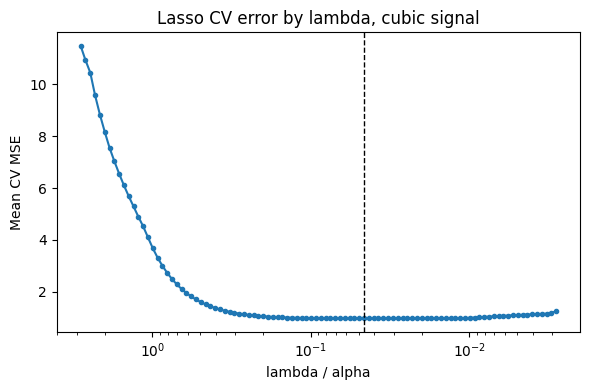

In [6]:
lasso = Pipeline([("scale", StandardScaler()), ("model", LassoCV(cv=10, random_state=RANDOM_STATE, max_iter=20000))])
lasso.fit(poly, Y)
lasso_model = lasso.named_steps["model"]
lasso_coef = pd.Series(lasso_model.coef_, index=poly.columns, name="lasso_coefficient_standardized_scale")
display(pd.DataFrame({
    "part": ["(e)"],
    "selected_lambda_alpha": [lasso_model.alpha_],
    "nonzero_terms": [tuple(lasso_coef[lasso_coef.abs() > 1e-6].index)],
}))
display(lasso_coef[lasso_coef.abs() > 1e-6])

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(lasso_model.alphas_, lasso_model.mse_path_.mean(axis=1), marker="o", markersize=3)
ax.axvline(lasso_model.alpha_, color="black", linestyle="--", linewidth=1)
ax.set_xscale("log")
ax.invert_xaxis()
ax.set_title("Lasso CV error by lambda, cubic signal")
ax.set_xlabel("lambda / alpha")
ax.set_ylabel("Mean CV MSE")
plt.tight_layout()

The lasso result is interpreted on the standardized predictor scale because the polynomial powers have very different raw magnitudes.  Nonzero coefficients show which powers survive shrinkage at the cross-validated lambda.  The curve should have a clear minimum or flat minimum region rather than an arbitrary penalty choice.

### Part (f): Sparse X^7 Response

The final simulation changes the true response to Y = 1 + 3X^7 + epsilon.  This tests whether forward stepwise selection and lasso can recover a sparse high-order signal rather than simply favoring low-order polynomial terms.

,part,selected_predictors_or_terms,criterion_or_lambda
0,(f) forward stepwise,"(X^7, X^10)",1.790691
1,(f) lasso,"(X^5, X^6, X^7)",0.095526


const    0.982928
X^7      3.005567
X^10    -0.001316
Name: forward_sparse_cp_coefficients, dtype: float64

X^5     0.208155
X^6    -0.034248
X^7    71.976603
Name: lasso_sparse_coefficient_standardized_scale, dtype: float64

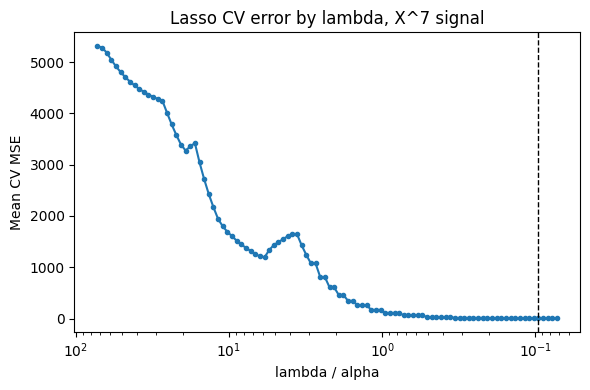

In [7]:
eps_sparse = rng.normal(size=n)
Y_sparse = 1 + 3 * X_raw**7 + eps_sparse
forward_sparse_table, forward_sparse_best = selection_path(Y_sparse, poly, "forward")
lasso_sparse = Pipeline([("scale", StandardScaler()), ("model", LassoCV(cv=10, random_state=RANDOM_STATE, max_iter=20000))])
lasso_sparse.fit(poly, Y_sparse)
lasso_sparse_model = lasso_sparse.named_steps["model"]
lasso_sparse_coef = pd.Series(lasso_sparse_model.coef_, index=poly.columns, name="lasso_sparse_coefficient_standardized_scale")
display(pd.DataFrame({
    "part": ["(f) forward stepwise", "(f) lasso"],
    "selected_predictors_or_terms": [
        forward_sparse_best["predictors"],
        tuple(lasso_sparse_coef[lasso_sparse_coef.abs() > 1e-6].index),
    ],
    "criterion_or_lambda": [forward_sparse_best["cp"], lasso_sparse_model.alpha_],
}))
display(forward_sparse_best["fit"].params.rename("forward_sparse_cp_coefficients"))
display(lasso_sparse_coef[lasso_sparse_coef.abs() > 1e-6])

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(lasso_sparse_model.alphas_, lasso_sparse_model.mse_path_.mean(axis=1), marker="o", markersize=3)
ax.axvline(lasso_sparse_model.alpha_, color="black", linestyle="--", linewidth=1)
ax.set_xscale("log")
ax.invert_xaxis()
ax.set_title("Lasso CV error by lambda, X^7 signal")
ax.set_xlabel("lambda / alpha")
ax.set_ylabel("Mean CV MSE")
plt.tight_layout()

The sparse-response results should give special weight to X^7 because that is the term used to generate Y.  Extra selected powers are still plausible because X, X^2, ..., X^10 are all deterministic transformations of the same predictor and can be strongly related in a sample of n = 100.  The important point is that the high-order signal is visible in both the stepwise and lasso results.

## Kaggle Regularization and PCR

The Abalone competition provides the prediction setting for the regularization and PCR portion of the assignment.  The shared data preparation keeps the validation split, preprocessing, and baseline constant, so differences between the elastic net and PCR ridge results come from the modeling approach rather than from different samples or feature handling.

In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.linear_model import ElasticNetCV, Ridge
from sklearn.metrics import mean_squared_log_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

abalone_raw = pd.read_csv(KAGGLE / "playground-series-s4e4" / "train.csv")
expected_columns = {"id", "Sex", "Length", "Diameter", "Height", "Whole weight", "Whole weight.1", "Whole weight.2", "Shell weight", "Rings"}
missing_expected = sorted(expected_columns - set(abalone_raw.columns))
duplicate_ids = int(abalone_raw["id"].duplicated().sum()) if "id" in abalone_raw else 0
missing_by_column = abalone_raw.isna().sum()
numeric_cols_raw = abalone_raw.select_dtypes(include=np.number).columns.tolist()
physical_cols = [c for c in numeric_cols_raw if c not in ["id", "Rings"]]
nonpositive_physical = {c: int((abalone_raw[c] <= 0).sum()) for c in physical_cols}
display(pd.DataFrame({
    "quality_check": ["rows", "columns", "missing_expected_columns", "duplicate_ids", "total_missing_values", "nonpositive_physical_values"],
    "value": [len(abalone_raw), abalone_raw.shape[1], missing_expected, duplicate_ids, int(missing_by_column.sum()), nonpositive_physical],
}))

abalone = abalone_raw.copy()
if missing_expected:
    raise ValueError(f"Missing expected Abalone columns: {missing_expected}")
if duplicate_ids:
    abalone = abalone.drop_duplicates(subset=["id"], keep="first")
if abalone["Rings"].isna().any():
    abalone = abalone.dropna(subset=["Rings"])
for col in physical_cols:
    abalone.loc[abalone[col] <= 0, col] = np.nan
display(abalone.isna().sum().rename("missing_after_cleaning_flags").to_frame().query("missing_after_cleaning_flags > 0"))

X = abalone.drop(columns=["Rings"])
y = abalone["Rings"]
cat = ["Sex"]; num = [c for c in X.columns if c not in cat + ["id"]]
cat_pipe = Pipeline([("impute", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))])
num_pipe = Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())])
pre = ColumnTransformer([("cat", cat_pipe, cat), ("num", num_pipe, num)])
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=.2, random_state=RANDOM_STATE)
baseline_pred = np.repeat(y_train.mean(), len(y_valid))
baseline_rmsle = np.sqrt(mean_squared_log_error(y_valid, baseline_pred))
display(pd.DataFrame({
    "setup_check": ["training_rows", "validation_rows", "mean_baseline_rmsle", "target_min", "target_max"],
    "value": [len(X_train), len(X_valid), baseline_rmsle, y.min(), y.max()],
}))
display(y.describe().rename("rings_summary").to_frame())

,quality_check,value
0,rows,90615
1,columns,10
2,missing_expected_columns,[]
3,duplicate_ids,0
4,total_missing_values,0
5,nonpositive_physical_values,"{'Length': 0, 'Diameter': 0, 'Height': 6, 'Who..."


,missing_after_cleaning_flags
Height,6


,setup_check,value
0,training_rows,72492.000000
1,validation_rows,18123.000000
2,mean_baseline_rmsle,0.290949
3,target_min,1.000000
4,target_max,29.000000


,rings_summary
count,90615.000000
mean,9.696794
std,3.176221
min,1.000000
25%,8.000000
50%,9.000000
75%,11.000000
max,29.000000


### Kaggle Model 1: Elastic Net Regularized Regression

The first Kaggle model is elastic net regression.  It fits the regularization requirement well because it keeps the Abalone measurements visible while shrinking unstable coefficients created by overlapping size and weight predictors.

In [9]:
elastic_model = Pipeline([
    ("pre", pre),
    ("model", ElasticNetCV(l1_ratio=[.1, .5, .9], cv=5, random_state=RANDOM_STATE, max_iter=20000)),
])
elastic_model.fit(X_train, y_train)
elastic_pred = np.maximum(elastic_model.predict(X_valid), 1)
elastic_rmsle = np.sqrt(mean_squared_log_error(y_valid, elastic_pred))
feature_names = elastic_model.named_steps["pre"].get_feature_names_out()
elastic_coefs = pd.DataFrame({
    "feature": feature_names,
    "coefficient": elastic_model.named_steps["model"].coef_,
})
elastic_coefs["abs_coefficient"] = elastic_coefs["coefficient"].abs()
display(pd.DataFrame({
    "model": ["Elastic net"],
    "validation_rmsle": [elastic_rmsle],
    "alpha": [elastic_model.named_steps["model"].alpha_],
    "l1_ratio": [elastic_model.named_steps["model"].l1_ratio_],
    "submission_file": ["A3_elastic_net_playground_series_s4e4.csv"],
}))
display(elastic_coefs.sort_values("abs_coefficient", ascending=False).head(12))

,model,validation_rmsle,alpha,l1_ratio,submission_file
0,Elastic net,0.165555,0.002452,0.9,A3_elastic_net_playground_series_s4e4.csv


,feature,coefficient,abs_coefficient
7,num__Whole weight.1,-3.122784,3.122784
9,num__Shell weight,2.778650,2.778650
6,num__Whole weight,1.462550,1.462550
5,num__Height,0.753645,0.753645
1,cat__Sex_I,-0.683837,0.683837
8,num__Whole weight.2,-0.596057,0.596057
4,num__Diameter,0.572421,0.572421
0,cat__Sex_F,0.016426,0.016426
3,num__Length,-0.000789,0.000789
2,cat__Sex_M,0.000000,0.000000


The elastic net validation RMSLE is below the mean baseline, which shows that the regularized model is learning signal rather than only reproducing the average ring count.  The coefficient table is the main interpretation output: after one-hot encoding sex and scaling numeric measurements, the largest coefficients identify the physical measurements that still matter after shrinkage.  That is why this model is a better explanatory baseline than a black-box model for this part of the assignment.

### Kaggle Model 2: PCR Ridge Regression

The second Kaggle model is PCR ridge.  This model answers a different question from elastic net: instead of shrinking the original predictors directly, it compresses the preprocessed measurements into principal components before ridge regression.

In [10]:
pcr_model = Pipeline([
    ("pre", pre),
    ("pca", PCA(n_components=.95)),
    ("model", Ridge(alpha=10)),
])
pcr_model.fit(X_train, y_train)
pcr_pred = np.maximum(pcr_model.predict(X_valid), 1)
pcr_rmsle = np.sqrt(mean_squared_log_error(y_valid, pcr_pred))
display(pd.DataFrame({
    "model_detail": ["validation_rmsle", "pcr_components_retained", "pcr_explained_variance", "submission_file"],
    "value": [
        pcr_rmsle,
        pcr_model.named_steps["pca"].n_components_,
        pcr_model.named_steps["pca"].explained_variance_ratio_.sum(),
        "A3_pcr_ridge_playground_series_s4e4.csv",
    ],
}))

,model_detail,value
0,validation_rmsle,0.186728
1,pcr_components_retained,4
2,pcr_explained_variance,0.96643
3,submission_file,A3_pcr_ridge_playground_series_s4e4.csv


The PCR ridge model improves on the mean baseline but gives up some direct interpretation because the predictors have been rotated into principal components.  The number of retained components and explained-variance total are therefore part of the result, not just technical details.  In this run, PCR is useful as a dimensionality-reduction comparison, but elastic net remains easier to interpret because its coefficients still point back to specific Abalone measurements (Jolliffe, 2002).

In [11]:
kaggle_a3_comparison = pd.DataFrame([
    {"model": "Mean baseline", "validation_rmsle": baseline_rmsle, "submission_file": ""},
    {"model": "Elastic net", "validation_rmsle": elastic_rmsle, "submission_file": "A3_elastic_net_playground_series_s4e4.csv"},
    {"model": "PCR ridge", "validation_rmsle": pcr_rmsle, "submission_file": "A3_pcr_ridge_playground_series_s4e4.csv"},
]).sort_values("validation_rmsle")
display(kaggle_a3_comparison)

,model,validation_rmsle,submission_file
1,Elastic net,0.165555,A3_elastic_net_playground_series_s4e4.csv
2,PCR ridge,0.186728,A3_pcr_ridge_playground_series_s4e4.csv
0,Mean baseline,0.290949,


The model comparison favors elastic net on validation RMSLE and interpretability.  PCR ridge still belongs in the analysis because it addresses collinearity through dimension reduction, but the transformed components make the substantive reading weaker.  The evidence cell below ties the two modeling sections to the actual Kaggle submissions.

In [12]:
import re

status_path = SUBMISSIONS / "kaggle_submission_status_playground-series-s4e4.txt"
for encoding in ("utf-16", "utf-8"):
    try:
        text = status_path.read_text(encoding=encoding)
        break
    except UnicodeError:
        continue

records = []
for line in text.splitlines():
    parts = re.split(r"\s{2,}", line.strip())
    if len(parts) >= 7 and parts[0].isdigit() and "A3_" in parts[1]:
        records.append({
            "ref": parts[0],
            "fileName": parts[1],
            "date": parts[2],
            "description": parts[3],
            "status": parts[4],
            "publicScore": parts[5],
            "privateScore": parts[6],
        })

display(pd.DataFrame(records))
display(pd.DataFrame({
    "submission_file": ['A3_elastic_net_playground_series_s4e4.csv', 'A3_pcr_ridge_playground_series_s4e4.csv'],
    "exists_locally": [(SUBMISSIONS / file).exists() for file in ['A3_elastic_net_playground_series_s4e4.csv', 'A3_pcr_ridge_playground_series_s4e4.csv']],
}))
display(pd.DataFrame({
    "evidence": ["Public GitHub repository", "Notebook path in repository"],
    "value": [
        "https://github.com/maldo81/dds-8555-predictive-analysis",
        "Week 3/Assignment 3/MaldonadoJDDS8555-3.ipynb",
    ],
}))

,ref,fileName,date,description,status,publicScore,privateScore
0,52966794,A3_pcr_ridge_playground_series_s4e4.csv,2026-05-23 21:27:17.190000,DDS-8555 A3 principal components ridge,SubmissionStatus.COMPLETE,0.18220,0.18228
1,52966791,A3_elastic_net_playground_series_s4e4.csv,2026-05-23 21:27:14.550000,DDS-8555 A3 elastic net regularization,SubmissionStatus.COMPLETE,0.16444,0.16373


,submission_file,exists_locally
0,A3_elastic_net_playground_series_s4e4.csv,True
1,A3_pcr_ridge_playground_series_s4e4.csv,True


,evidence,value
0,Public GitHub repository,https://github.com/maldo81/dds-8555-predictive...
1,Notebook path in repository,Week 3/Assignment 3/MaldonadoJDDS8555-3.ipynb


## Interpretation

The regularized model is the better fit for this stage of the assignment because it keeps the original predictors visible while shrinking unstable coefficients.  The elastic net coefficient table shows which standardized physical measurements retain signal after shrinkage, while the selected alpha and l1 ratio document the regularization strength chosen by cross-validation (Tibshirani, 1996).  PCR is useful as a dimensionality-reduction comparison, but its components are less directly interpretable because the predictors are rotated into principal components (Jolliffe, 2002).  The Kaggle evidence shows both submissions completed, and the public score favored the elastic net model over the PCR ridge model.  The Abalone context matters because rings are a biological age proxy, so the model should be interpreted as a measurement-based approximation rather than a causal aging model (Nash et al., 1994).

## References

Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The elements of statistical learning: Data mining, inference, and prediction* (2nd ed.).  Springer. https://doi.org/10.1007/978-0-387-84858-7

Jolliffe, I.  T. (2002). *Principal component analysis* (2nd ed.).  Springer. https://doi.org/10.1007/b98835

Nash, W.  J., Sellers, T.  L., Talbot, S.  R., Cawthorn, A.  J., & Ford, W.  B. (1994). *The population biology of abalone (Haliotis species) in Tasmania.  I.  Blacklip abalone (H. rubra) from the north coast and islands of Bass Strait* (Technical Report No.  48).  Sea Fisheries Division.

Tibshirani, R. (1996).  Regression shrinkage and selection via the lasso. *Journal of the Royal Statistical Society: Series B, 58*(1), 267-288. https://doi.org/10.1111/j.2517-6161.1996.tb02080.x